In [3]:
#import labraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [4]:
#1. import database / data

In [5]:
conn =sqlite3.connect('customer_churn.db')

sql_query = """
       SELECT name
       FROM sqlite_master
       WHERE type='table'
"""

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [6]:
# Print each table and its columns

conn =sqlite3.connect('customer_churn.db')

for table_name in tables["name"]:
    
    print(f"\nTable Name: {table_name}")
    
    columns_query = f"PRAGMA table_info({table_name})"
    columns = pd.read_sql(columns_query, conn)
    
    print("Columns:")
    print(columns["name"].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [7]:
#2. data cleaning

In [8]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [9]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  221 non-null    str   
 1   name        221 non-null    str   
 2   country     188 non-null    str   
 3   state       221 non-null    str   
 4   gender      221 non-null    str   
 5   dob         221 non-null    str   
 6   interests   43 non-null     str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 13.9+ KB


In [10]:
#1. rename - name
#2. drop columns- interest and pincode
#3. change data type - dob
#4. data standardization - gender
#5. fix missing values - country

In [11]:
#1. rename - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
...,...,...,...,...,...,...,...,...
216,0264-AAVCD,raghvendra,India,Delhi,Male,1979-01-15 00:00:00,NaN,None
217,0126-FBJLZ,shiva,India,Meghalaya,Male,1979-04-06 00:00:00,NaN,None
218,0434-MOIMW,parvati,India,Meghalaya,Male,1980-01-27 00:00:00,drama,None
219,0472-FTMYL,rishabh,India,Maharashtra,Male,1996-09-01 00:00:00,NaN,None


In [12]:
#2. drop columns- interest and pincode
df_db_customer.drop(columns= {'interests','pincode'},inplace= True)

In [13]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
...,...,...,...,...,...,...
216,0264-AAVCD,raghvendra,India,Delhi,Male,1979-01-15 00:00:00
217,0126-FBJLZ,shiva,India,Meghalaya,Male,1979-04-06 00:00:00
218,0434-MOIMW,parvati,India,Meghalaya,Male,1980-01-27 00:00:00
219,0472-FTMYL,rishabh,India,Maharashtra,Male,1996-09-01 00:00:00


In [14]:
#3. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [15]:
#4. data standardization - gender

df_db_customer['gender']= df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [16]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [17]:
#5. fix missing Values - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01
27,0590-AVXDV,vishakha,NaN,Kathmandu,Female,1980-01-02
40,0573-KADIF,raghvendra,NaN,Kathmandu,Male,1979-11-12
63,0857-YRBOC,shiva,NaN,Kathmandu,Female,1980-03-14
64,0798-PUOYB,mina,NaN,Kathmandu,Male,1980-11-16
75,0847-DOCEY,madan,NaN,Telangana,Male,1991-05-29
103,0463-ATLHS,raju,NaN,Delhi,Male,1998-06-25
106,0215-PWPLZ,rikim,NaN,Kathmandu,Male,1994-01-16


In [18]:
# country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [20]:
 # Checking df_db_subscription.info()
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               221 non-null    str    
 1   subscription_start_date  221 non-null    str    
 2   subscription_type        221 non-null    str    
 3   renewal_date             221 non-null    str    
 4   plan_type                221 non-null    str    
 5   contract_type            221 non-null    str    
 6   cancellation_date        78 non-null     str    
 7   cancellation_reason      78 non-null     str    
 8   monthly_charges          221 non-null    float64
 9   cltv                     221 non-null    int64  
 10  churn_score              221 non-null    int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 19.1 KB


In [21]:
# change data type - date
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()


<class 'pandas.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               221 non-null    str           
 1   subscription_start_date  221 non-null    datetime64[us]
 2   subscription_type        221 non-null    str           
 3   renewal_date             221 non-null    datetime64[us]
 4   plan_type                221 non-null    str           
 5   contract_type            221 non-null    str           
 6   cancellation_date        78 non-null     datetime64[us]
 7   cancellation_reason      78 non-null     str           
 8   monthly_charges          221 non-null    float64       
 9   cltv                     221 non-null    int64         
 10  churn_score              221 non-null    int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 19.1 KB


In [22]:
# checking df_db_support
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [23]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      102 non-null    str   
 1   complaint_date  102 non-null    str   
 2   escalations     102 non-null    str   
 3   csat_score      102 non-null    int64 
 4   col_1           0 non-null      object
 5   comment         81 non-null     str   
dtypes: int64(1), object(1), str(4)
memory usage: 4.9+ KB


In [24]:
# drop column - col_1 and comment
df_db_support.drop(columns = ['col_1','comment'], inplace= True)

In [25]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      102 non-null    str  
 1   complaint_date  102 non-null    str  
 2   escalations     102 non-null    str  
 3   csat_score      102 non-null    int64
dtypes: int64(1), str(3)
memory usage: 3.3 KB


In [26]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [27]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      102 non-null    str           
 1   complaint_date  102 non-null    datetime64[us]
 2   escalations     102 non-null    str           
 3   csat_score      102 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 3.3 KB


In [28]:
#3. Feature Engineering and Data Analysis

In [29]:
# creat a new column using existed column - churn_flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [30]:
df_db_subscription.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
#first fix support table duplicates then merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [32]:
df.shape

(240, 20)

In [33]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [34]:
df_db_customer['customerid'].nunique()

221

In [35]:
df_db_subscription['customerid'].nunique()

221

In [36]:
df_db_support['customerid'].nunique()

83

In [37]:
df_db_support['customerid'].size

102

In [38]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
97,0614-YFPZY,2024-01-26,Y,10
98,0614-YFPZY,2024-04-08,N,54
99,0073-TBVDU,2026-09-18,N,89
100,0741-ENDQX,2024-03-01,N,71


In [39]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [40]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [41]:
df_db_support['customerid'].size

83

In [42]:
#merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [43]:
df.shape

(221, 21)

In [44]:
# data analysis

In [45]:
#1. Churn Rate

In [46]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ",round(churn_rate,2),"%")

Churn Rate =  35.29 %


In [47]:
#2. Retention Rate
retention_rate = 100-churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  64.71 %


In [48]:
#3. churn by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           36.25
1   Premium           27.12
2  Standard           40.24


In [49]:
#4. a. Churn by state + sum(revenue) & count of users
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', 'mean'),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('churn_flag', 'count')
      )
      .reset_index()
)

churn_by_state['churn_rate_pct'] = churn_by_state['churn_rate_pct'].mul(100).round(2)

print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           41.86         859.57          43
1      Karnataka           50.00         255.82          18
2      Kathmandu           24.00         555.75          25
3    Maharashtra           32.26         594.69          31
4      Meghalaya           28.57         697.72          28
5       Nagaland           33.33         196.88          12
6      Rajasthan           33.33         442.73          27
7      Telangana           26.32         643.81          19
8  Uttar Pradesh           50.00         602.82          18


In [50]:
#4. b. Churn by subscription type + sum(revenue) & count of users
churn_by_subscription_type = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', 'mean'),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('churn_flag', 'count')
      )
      .reset_index()
)

churn_by_subscription_type['churn_rate_pct'] = churn_by_subscription_type['churn_rate_pct'].mul(100).round(2)

print(churn_by_subscription_type)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic           30.49        1899.18          82
1              Paid           37.50        1684.28          72
2          Refferal           38.81        1266.33          67


In [51]:
#5. ARPU - Average revenue per user
arpu = df['monthly_charges'].mean().round(2)
print("ARPU = ",arpu)

ARPU =  21.94


In [52]:
#6. Avg Customer Tenure
# count of days user has used our service: cancellation date else current date
today = pd.Timestamp.today() 

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
       
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ",round(avg_tenure),0)


Avg Tenure (Days) =  1228 0


In [53]:
#7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') = ",revenue_at_risk)

Revenue at Risk (Rs 'K') =  1715.2200000000003


In [54]:
#8. Escilation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate: ",round(escalation_rate,2),"%")

Escalation Rate:  13.12 %


In [55]:
#9. Avg Complaint per user
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Complaint per user = ",round(avg_complaints,2))


Avg Complaint per user =  0.46


In [56]:
#10. correlation esclation vs churn

df['escalations'] = np.where(df['escalations']=='Y',1,0) #encoding  string to int type
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn is= ",round(correlation,2))


Correlation between escalation vs churn is=  0.08


In [57]:
#11. Churn risk - create a column using existing col
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [58]:
df[['churn_score', 'churn_risk']].tail()

,churn_score,churn_risk
216,19,low
217,29,low
218,31,low
219,80,high
220,70,high


In [59]:
#12. Total & Churned Customers
total_customers = df['customerid'].nunique()
churned_customers = df.loc[df['churn_flag']==1, 'customerid'].nunique()
print("Total Customers = ", total_customers)
print("Churned Customers = ", churned_customers)

Total Customers =  221
Churned Customers =  78


In [60]:
#13. Avg Churn Score
avg_churn_score = df['churn_score'].mean()
print("Avg Churn Score = ", round(avg_churn_score,2))

Avg Churn Score =  47.5


In [61]:
#14. MRR - Monthly Recurring Revenue (from active users)
mrr = df.loc[df['churn_flag']==0, 'monthly_charges'].sum()
print("MRR (Active Users) = ", round(mrr,2))

MRR (Active Users) =  3134.57


In [62]:
#15. Avg Customer Lifetime Value (CLTV)
avg_cltv = df['cltv'].mean()
print("Avg CLTV = ", round(avg_cltv,2))

Avg CLTV =  1439.62


In [63]:
#16. Churn by Contract Type
churn_by_contract = (df.groupby('contract_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_contract)

  contract_type  churn_rate_pct
0        Annual           37.38
1       Monthly           33.33


In [64]:
#17. Avg CSAT Score
avg_csat = df['csat_score'].mean()
print("Avg CSAT Score = ", round(avg_csat,2))

Avg CSAT Score =  49.46


In [65]:
#18. Top Cancellation Reasons
top_cancel_reasons = df['cancellation_reason'].value_counts()
print(top_cancel_reasons)

cancellation_reason
Forgot to cancel trial    18
Too expensive             17
Poor streaming quality    16
Not enough content        14
Switched to competitor    13
Name: count, dtype: int64


In [66]:
#4. Visualization using Matplotlib

In [67]:
df_visual = df.copy()

In [68]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

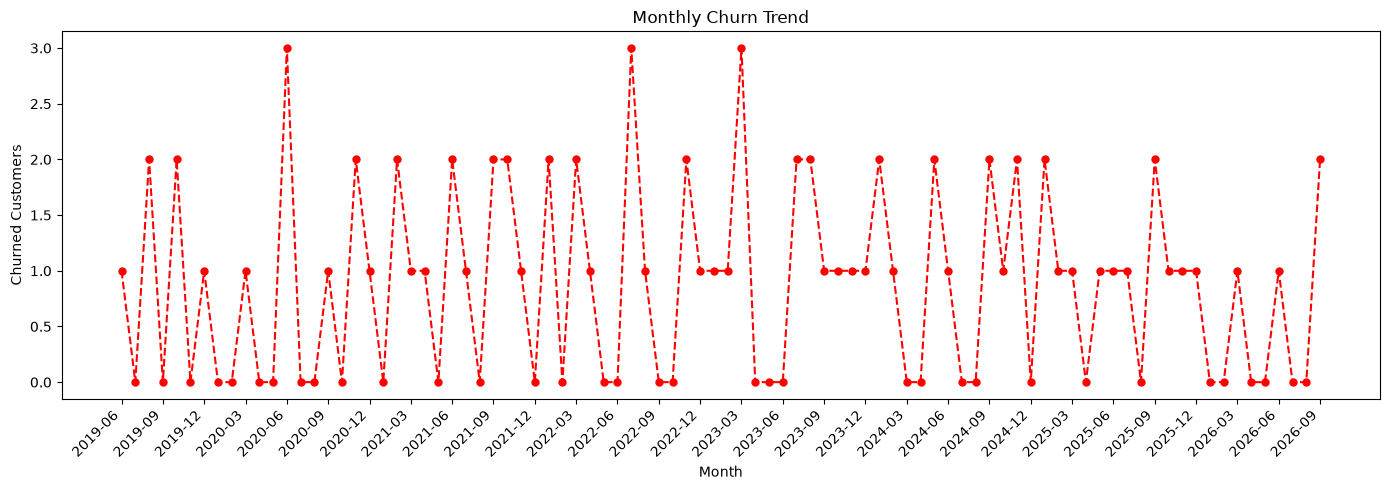

In [69]:
#4.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

# fill in months with zero churns so the line doesn't skip/compress oddly
full_range = pd.period_range(churn_trend.index.min(), churn_trend.index.max(), freq='M')
churn_trend = churn_trend.reindex(full_range, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(churn_trend.index.astype(str), churn_trend.values,
        color='red', marker='o', linestyle='dashed', linewidth=1.5, markersize=5)
ax.set_title('Monthly Churn Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Churned Customers')

# only show every 3rd label so the x-axis isn't crowded
ax.set_xticks(range(0, len(churn_trend), 3))
ax.set_xticklabels(churn_trend.index.astype(str)[::3], rotation=45, ha='right')

plt.tight_layout()
plt.show()

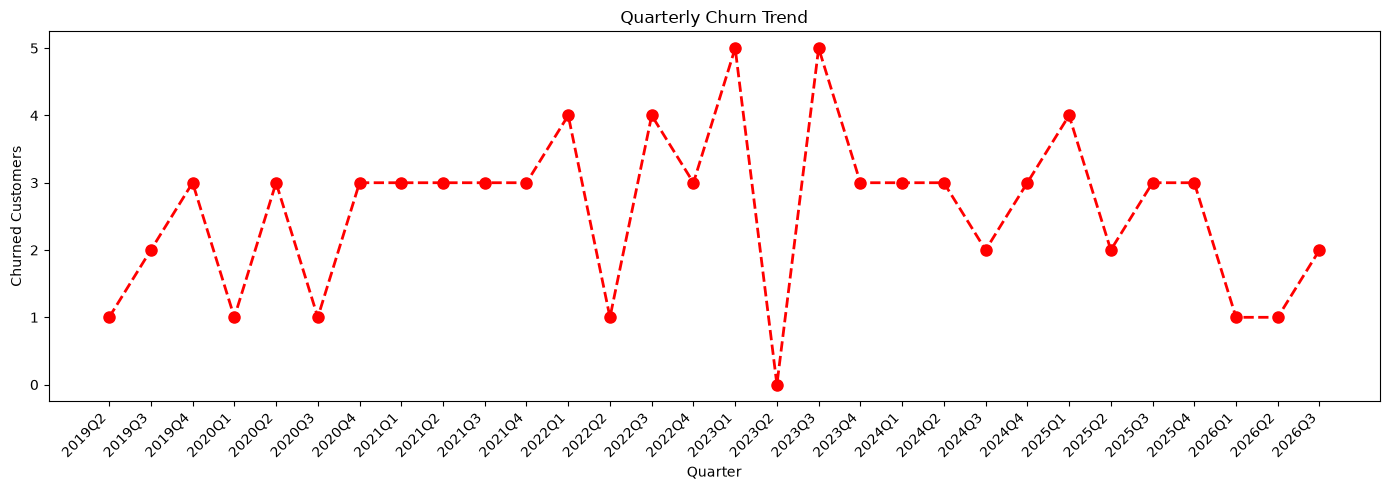

In [70]:
#4.2 Quarterly Churn Trend (Time Series KPI)
df_visual['cancellation_quarter'] = df_visual['cancellation_date'].dt.to_period('Q')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_quarter').size()
full_range = pd.period_range(churn_trend.index.min(), churn_trend.index.max(), freq='Q')
churn_trend = churn_trend.reindex(full_range, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(churn_trend.index.astype(str), churn_trend.values,
        color='red', marker='o', linestyle='dashed', linewidth=2, markersize=8)
ax.set_title('Quarterly Churn Trend')
ax.set_xlabel('Quarter')
ax.set_ylabel('Churned Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

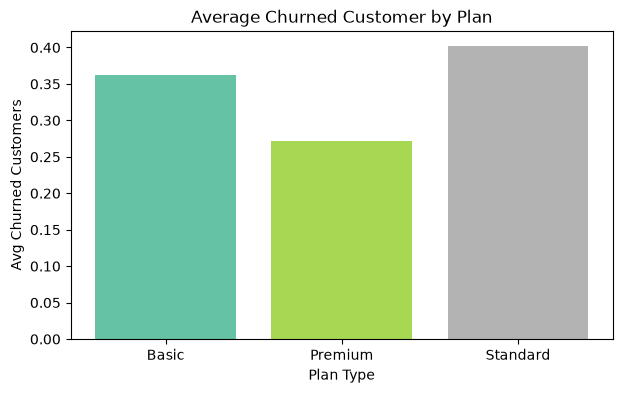

In [71]:
#4.3 Churn by Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# for dynamic colors
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize = (7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title('Average Churned Customer by Plan')
plt.xlabel('Plan Type')
plt.ylabel('Avg Churned Customers')
plt.show()

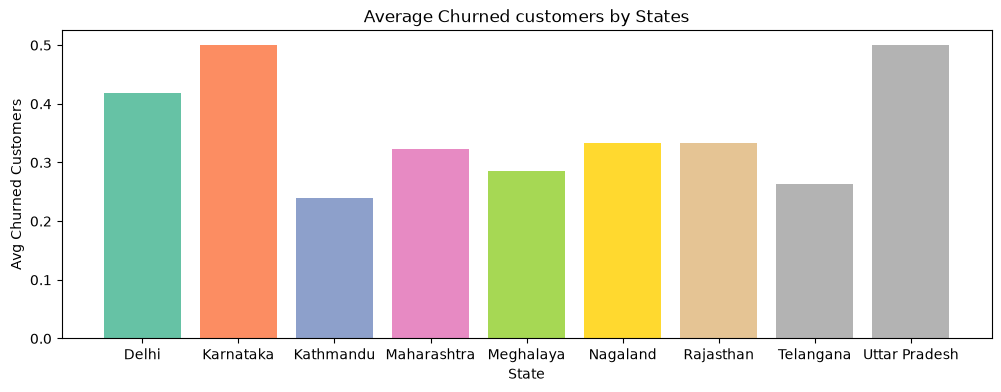

In [72]:
#4.4 Churn by State
churn_state = df_visual.groupby('state')['churn_flag'].mean()

# for dynamic colors
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_state)))

plt.figure(figsize = (12,4))

plt.bar(churn_state.index, churn_state.values, color = colors)
plt.title('Average Churned customers by States')
plt.xlabel('State')
plt.ylabel('Avg Churned Customers')
plt.show()

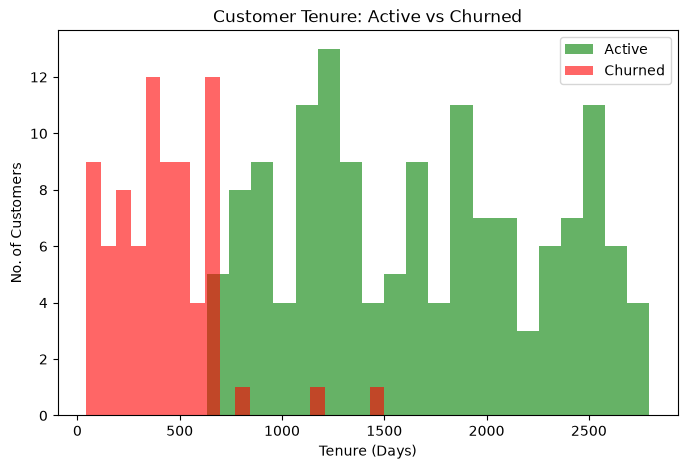

In [87]:
# 4.5 Ternure Distribution - how long customer stay before churning
plt.figure(figsize = (8,5))
plt.hist(df_visual[df_visual['churn_flag']==0]['tenure_days'], bins= 20,alpha=0.6,label='Active',color='green')
plt.hist(df_visual[df_visual['churn_flag']==1]['tenure_days'], bins= 20,alpha=0.6,label='Churned',color='red')
plt.title('Customer Tenure: Active vs Churned')
plt.xlabel('Tenure (Days)')
plt.ylabel('No. of Customers')
plt.legend()
plt.show()



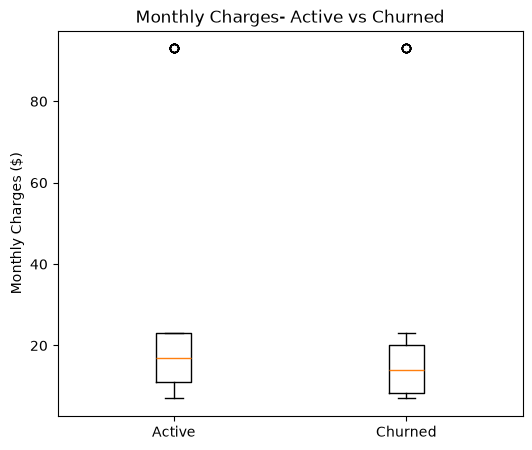

In [95]:
#4.6 Monthly charges- do churned customer pay more
# Box plot
plt.figure(figsize = (6,5))
plt.boxplot(
    [df_visual[df_visual['churn_flag']==0]['monthly_charges'],
    df_visual[df_visual['churn_flag']==1]['monthly_charges']],
     tick_labels=['Active','Churned']
)
plt.title('Monthly Charges- Active vs Churned')
plt.ylabel('Monthly Charges ($)')
plt.show()

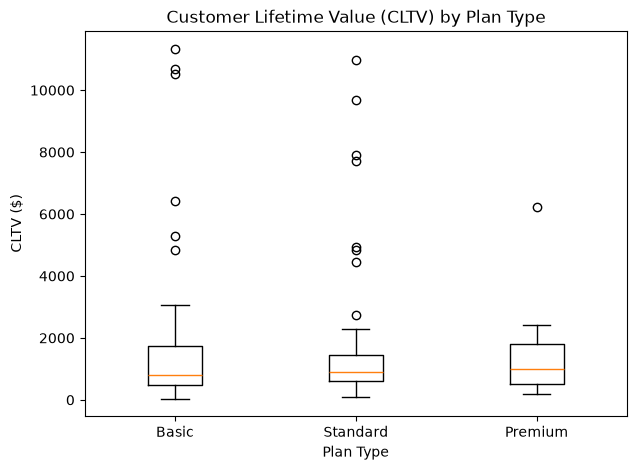

In [97]:
# CLTV by plan Type
plt.figure(figsize=(7,5))
plans = ['Basic','Standard','Premium']
data_by_plan = [df_visual[df_visual['plan_type']==p]['cltv'] for p in plans]
plt.boxplot(data_by_plan, tick_labels=plans)
plt.title('Customer Lifetime Value (CLTV) by Plan Type')
plt.ylabel('CLTV ($)')
plt.xlabel('Plan Type')
plt.show()

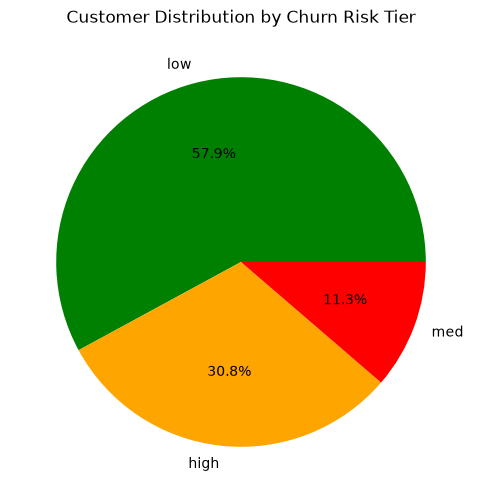

In [112]:
# pie_chart
risk_counts = df_visual['churn_risk'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', colors=['green','orange','red'])
plt.title('Customer Distribution by Churn Risk Tier')
plt.show()

In [74]:
# Visulaization using Seaborn

In [75]:
#encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month',
       'cancellation_quarter'],
      dtype='str')

In [76]:
df_visual[['plan_type','contract_type','churn_score', 'churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [77]:
# encoding - based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score', 'churn_flag','churn_risk','escalations']].copy()

order_mapping ={
    'plan_type' : ['Basic', 'Standard', 'Premium'],
     'contract_type' : ['Monthly', 'Annual'],
     'churn_risk' : ['low', 'med', 'high']
    }
for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes


In [78]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

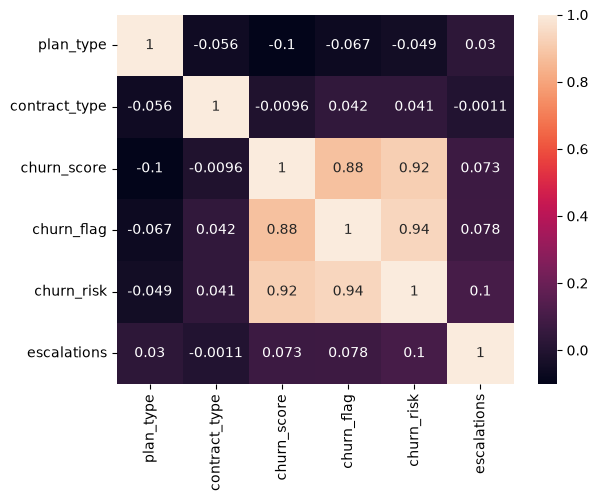

In [79]:
#Heatmap (Correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

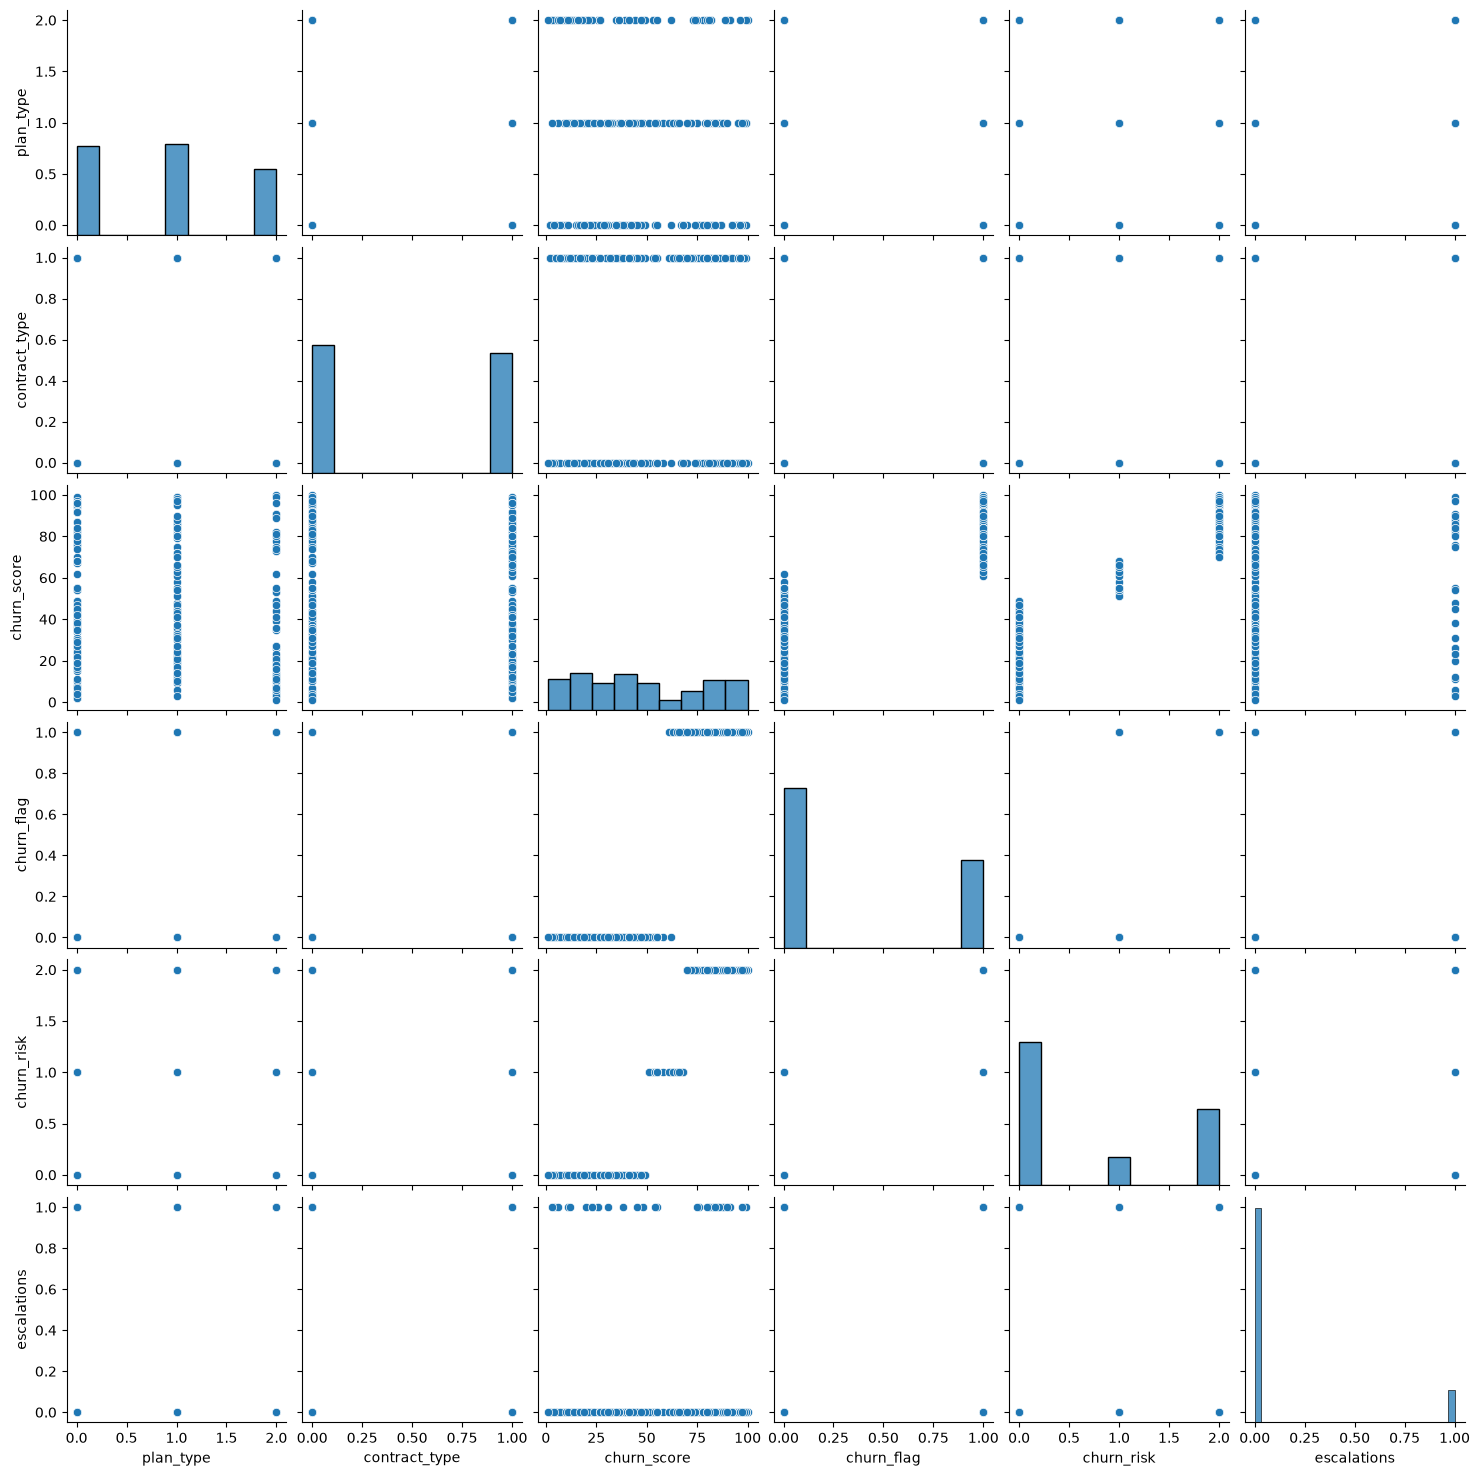

In [80]:
# pairplot - relationship in a dataset

sns.pairplot(df_encoded)

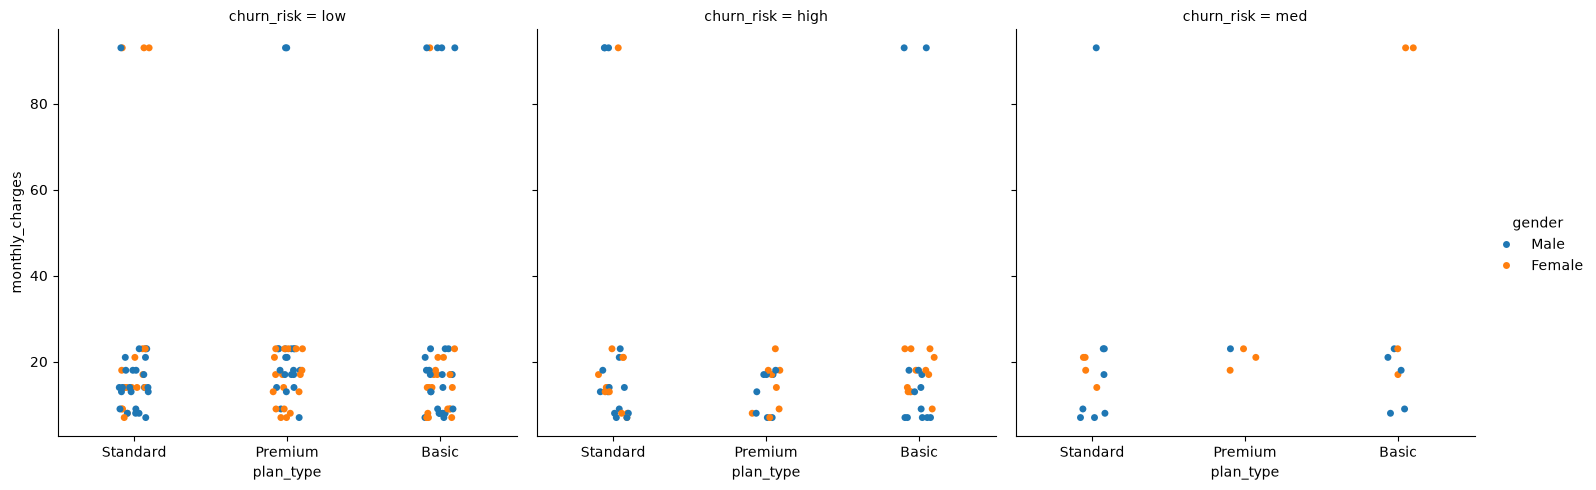

In [81]:
#catplt/Facegrid plot-multi-dim camparison

sns.catplot(data = df_visual,
           x = 'plan_type',
           y = 'monthly_charges',
           hue = 'gender',
           col = 'churn_risk')

In [82]:
# Pivot Table

In [84]:
#Revenue at Risk by Plan Type 
pivot_risk = pd.pivot_table(
    df, index='plan_type', columns='churn_risk', values='monthly_charges',
    aggfunc='sum', margins=True, margins_name='Total'
).round(2)

pivot_risk = pivot_risk[['low', 'med', 'high', 'Total']]
pivot_risk.columns = ['Low Risk ($)', 'Medium Risk ($)', 'High Risk ($)', 'Total Revenue ($)']
pivot_risk.index.name = 'Plan Type'

print(pivot_risk)


           Low Risk ($)  Medium Risk ($)  High Risk ($)  Total Revenue ($)
Plan Type                                                                 
Basic           1023.54           304.91         514.75            1843.20
Premium          812.61            84.96         217.84            1115.41
Standard         944.57           260.88         685.73            1891.18
Total           2780.72           650.75        1418.32            4849.79
